# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items(): #словарь базовых моделей
    scores = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1,
    verbose=1               # чтобы видеть сам процесс поиска
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
import pandas as pd
results_df = pd.DataFrame(svm_grid_search.cv_results_)
columns_to_show = [
    'params',            #сами комбинации параметров
    'mean_test_score',   #средний рез-т f1
    'std_test_score',    #отклонение(стабильность)
    'rank_test_score'    #место в рейтинге
]
top_10_configs = results_df[columns_to_show].sort_values('rank_test_score').head(10)
display(top_10_configs)


,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),         #кол-во деревьев
    'max_depth': [None] + list(range(2, 21)), #глубина, none значит не ограничена
    'min_samples_split': randint(2, 20),      #минимум объектов для разделения узла
    'max_features': ['sqrt', 'log2', 0.5]     #сколько признаков смотреть при поиске разбиения
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,          #сколько случайных комбинаций надо проверить
    cv=5, 
    scoring='f1_macro', 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры RF: {'max_depth': 7, 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 219}
Лучший CV F1: 0.9576


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [30]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print("отчет: SVM(grid search)")
y_pred_svm = svm_grid_search.predict(X_test)
print(classification_report(y_test, y_pred_svm))
print("\nотчет: Random Forest (random search)")
y_pred_rf = rf_random_search.predict(X_test)
print(classification_report(y_test, y_pred_rf))



print("\nрезультаты:")
print(f"| {'Модель':<18} | {'CV F1(mean±std)':<14} | {'Test F1':<7} |")
print(f"|{'-'*20}|{'-'*17}|{'-'*9}|")


mean_svm, std_svm = baseline_results['SVM']
print(f"| {'SVM baseline':<18} | {mean_svm:.4f} ± {std_svm:.4f} | {svm_base_test:<7.4f} |")

best_idx_svm = svm_grid_search.best_index_
std_grid_svm = svm_grid_search.cv_results_['std_test_score'][best_idx_svm]
print(f"| {'SVM Grid Search':<18} | {svm_grid_search.best_score_:.4f} ± {std_grid_svm:.4f} | {svm_test_f1:<7.4f} |")

mean_rf, std_rf = baseline_results['RandomForest']
print(f"| {'RF baseline':<18} | {mean_rf:.4f} ± {std_rf:.4f} | {rf_base_test:<7.4f} |")

best_idx_rf = rf_random_search.best_index_
std_rand_rf = rf_random_search.cv_results_['std_test_score'][best_idx_rf]
print(f"| {'RF Rand Search':<18} | {rf_random_search.best_score_:.4f} ± {std_rand_rf:.4f} | {rf_test_f1:<7.4f} |")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

отчет: SVM(grid search)
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


отчет: Random Forest (random search)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


результаты:
| Модель             | CV F1(mean±std) | Test F1 |
|--------------------|-----------------|---------|
| SVM baseline       | 0.9694 ± 0.0193 | 0.9812  |
| SVM Grid Search    | 0.9786 ± 0.0176 | 0.9812  |
| RF baseline        | 0.9504 ± 0.0255 | 0.9526  |
| RF Rand Search

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

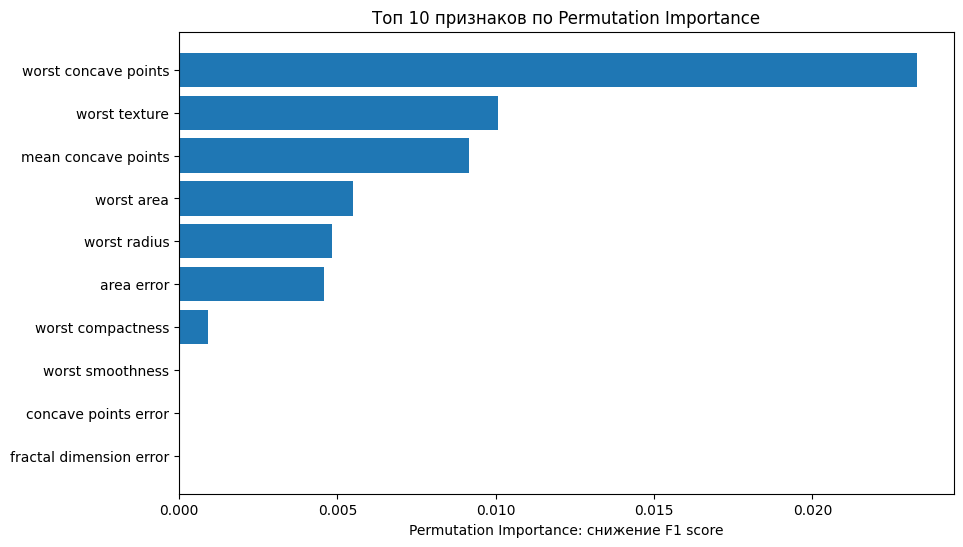

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1_macro'
)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
sorted_idx = pi_result.importances_mean.argsort()[-10:] 

plt.figure(figsize=(10, 6))
plt.barh(range(10), pi_result.importances_mean[sorted_idx])
plt.yticks(range(10), X_test.columns[sorted_idx])
plt.xlabel("Permutation Importance: снижение F1 score")
plt.title("Топ 10 признаков по Permutation Importance")
plt.show()

In [ ]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_imp_values = best_rf.feature_importances_
rf_imp_series = pd.Series(rf_imp_values, index=X_train.columns).sort_values(ascending=False)
pi_imp_series = pd.Series(pi_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Топ-5 признаков (Встроенная важность RF):")
print(rf_imp_series.head(5))
print("\nТоп-5 признаков (Permutation Importance):")
print(pi_imp_series.head(5))


"""
нет, порядок не совпадает

методы по-разному смотрят на данные:
встр важность MDI считает как часто признак использовался для разделения узлов при обучении,
отдает приоритет признакам где много уникальных значений даже если в них есть шум.
Permutation Importance PI оценивает вклад признака в качество предсказания на тестовых данных.
это более обьективно ибо показывает насколько модель ухудшится без этого признака.
""";




# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

"""
1)Высокий PI, но низкая встроенная важность
означает, что признак важен не сам по себе, но в взаимодействии с другими признаками. 
Встроенный метод может не оценить его вклад если он редко используется как основной разделитель
но PI покажет что без него рушится вся логика модели

2)Высокая встроенная важность, но низкий PI
означает переобучение или избыточность:
модель могла найти случайную закономерность в трейне и активно её использовать 
(высокая встроенная важность), но на тесте закономерность не работает(низкий PI).
Либо в данных есть сильная корреляция
""";

Топ-5 признаков (Встроенная важность RF):
worst perimeter         0.211995
worst concave points    0.182459
worst area              0.146852
worst radius            0.140294
mean concave points     0.115463
dtype: float64

Топ-5 признаков (Permutation Importance):
worst concave points    0.023306
worst texture           0.010080
mean concave points     0.009154
worst area              0.005509
worst radius            0.004828
dtype: float64


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

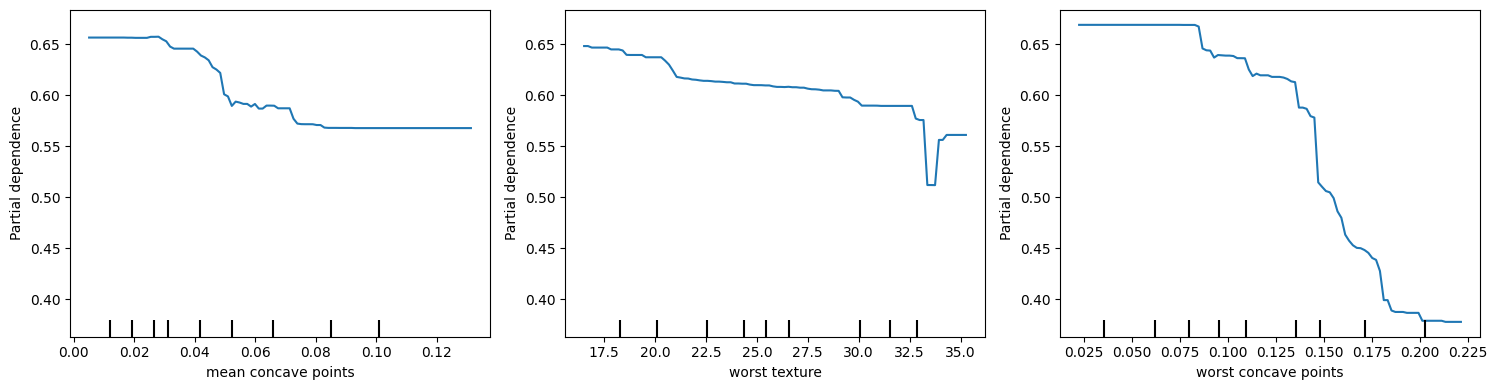

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_result.importances_mean.argsort()[-3:]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test, 
    features=top3_idx,  #индексы топ-3 признаков
    kind='average',     #классический pdp
    ax=ax               # рисовать
)

plt.tight_layout()
plt.show()

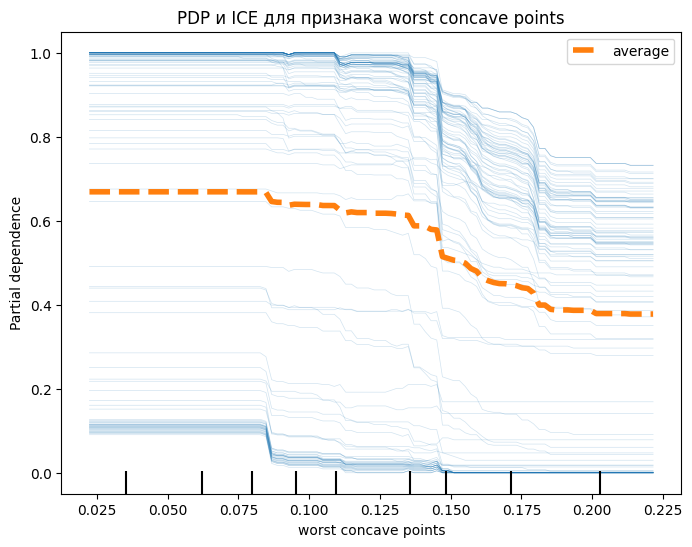

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_idx = pi_result.importances_mean.argsort()[-1:]
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=most_important_idx,
    kind='both',       #для pdp и ice вместе
    ice_lines_kw={"color": "tab:blue", "alpha": 0.2, "linewidth": 0.5}, #тонкие линии
    pd_line_kw={"color": "tab:orange", "linewidth": 4},    # жирная линия
    ax=ax
)

plt.title(f"PDP и ICE для признака {X_test.columns[most_important_idx[0]]}")
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
# Установка SHAP (если не установлен)
%pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(f"Форма массива shap_values: {np.array(shap_values).shape}")

Note: you may need to restart the kernel to use updated packages.
Форма массива shap_values: (114, 30, 2)


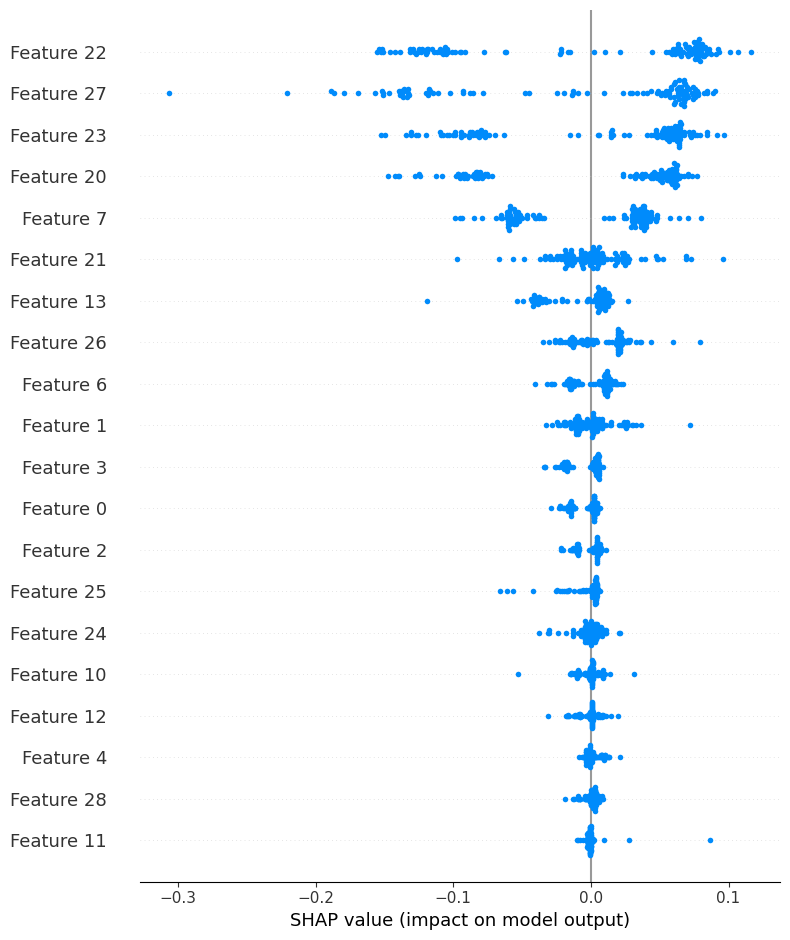

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
#shap.summary_plot(shap_values[1], X_test) хз почему не работает агрится чето
shap.summary_plot(shap_values[:, :, 1])






In [38]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
current_shap_values = shap_values[error_idx, :, 1]
shap.force_plot(
    explainer.expected_value[1],
    current_shap_values,
    X_test.iloc[error_idx]
)


Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

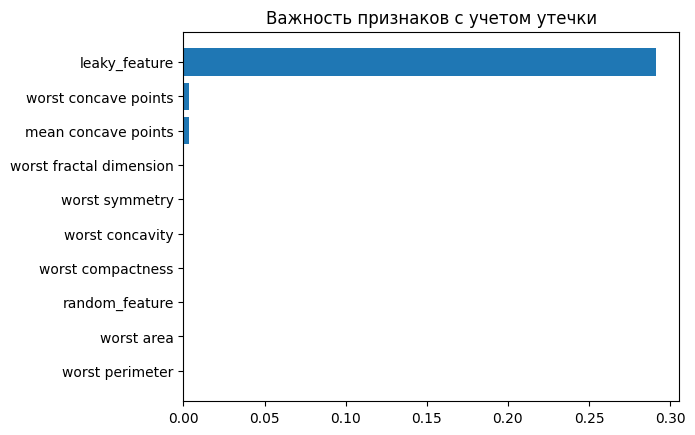

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
import numpy as np

#плохие признаки
X_train_leaky = X_train.copy()
X_test_leaky = X_test.copy()
X_train_leaky['leaky_feature'] = y_train + np.random.normal(0, 0.05, len(y_train))
X_test_leaky['leaky_feature'] = y_test + np.random.normal(0, 0.05, len(y_test))
#шум
X_train_leaky['random_feature'] = np.random.normal(0, 1, len(X_train))
X_test_leaky['random_feature'] = np.random.normal(0, 1, len(X_test))
rf_leaky = RandomForestClassifier(n_estimators=100, random_state=42) #обучение заново
rf_leaky.fit(X_train_leaky, y_train)
pi_leaky = permutation_importance(rf_leaky, X_test_leaky, y_test, n_repeats=5, random_state=42)
sorted_idx = pi_leaky.importances_mean.argsort()[-10:]
plt.barh(X_test_leaky.columns[sorted_idx], pi_leaky.importances_mean[sorted_idx])
plt.title("Важность признаков с учетом утечки")
plt.show()


"""
а) 
PI выводит leaky_feature на первое место с огромным отрывом. при его перемешивании 
метрика F1 падает почти до 0, что означает критическую зависимость модели от этого признака.
метрика выросла потому что признак имеет в себе ответ\таргет с мин шумом. модели больше не нужно 
анализировать сложные зависимости, хватит транслировать значения из этого признака.
б) 
на графике leaky_feature на самой верхней строке с самым длинным хвостом значений. 
синие низкие значения слева, а красные высокие справа. данный признак один обьясняет 
почти всё отклонение прогноза от базового значения, подавляет вклад всех остальных параметров.
в)
в PI: важность будет близка к нулю. наличие или отсутствие этого признака
никак не влияет на точность предсказания.
в SHAP: точки этого признака на summary plot будут перемешаны по цветам(синие и красные в одной куче)
 и сосредоточены вокруг центр линии. это признак того что модель не видит стабильной связи
 меж значением этого параметра и диагнозом.
""";





## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
"""
0.9694	0.98	
0.9786	0.98
0.9504	0.96
0.9576	0.96
Выводы:
(данные линейно разделимы а значит высокий результат)
(почти достигли самой высокой точности зато тюнинг сделал немного стабильнее)
(тут свм немного точнее рандом фореста)
(с тюнингом нашли более оптимальную глубину деревьев)


1)дал прирост примерно на 1% (с 0.969 до 0.978 для SVM)

2)PI и SHAP: совпали частично. оба раза первым был worst concave points. разница в остальном топе объясняется тем 
что SHAP лучше видит скрытые зависимости между признаками.

3)утечку данных ибо глянули параметры распределения теста
4) PI чтоб чистить данные, SHAP объяснять диагноз пациенту например.

""";

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
%pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    #пр-во поиска(диапазоны пар-ров)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    model = RandomForestClassifier( #модель
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='f1_macro').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 21.0 MB/s eta 0:00:00
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)
Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl (154 kB)

   ---------------------------------------- 0/8 [PyYAML]
   ---------- ----------------------------- 2/8 [greenlet]
   ---------- ----------------------------- 2/8 [greenlet]
   ---------- ----------------------------- 2/8 [greenlet]
   -------------------- ------------------- 4/8 [sqlalchemy]
   -------------------- ------------------- 4/8 [sqlalchemy]
   -------------------- ------------------- 4/8 [sqlalchemy]
   -------------------- ------------------- 4/8 [sqlalchemy]
   -------------------- ------------------- 4/8 [sqlalchemy]
   -------------------- -----------------